<a href="https://colab.research.google.com/github/SweathaAngappan/CropYieldPredictionUsingMachineLearning/blob/main/Another_copy_of_Crop_yield_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import scipy.stats as stats
import matplotlib.pyplot as plt
import sklearn
import seaborn as sns
from sklearn.model_selection import train_test_split
import statsmodels.formula.api as smf
import math
import seaborn as sb
from sklearn.ensemble import RandomForestRegressor

In [ ]:
!pip install pandas
import pandas as pd # Make sure pandas is imported with the alias "pd"

from google.colab import files
uploaded=files.upload()
for fn in uploaded.keys():
  print('user"{name}" with length {length} bytes'.format(name=fn,length=len(uploaded[fn])))
data=pd.read_csv("Cropdataset.csv")
data

Saving Cropdataset.csv to Cropdataset (2).csv
user"Cropdataset (2).csv" with length 1601658 bytes


,State_Name,District_Name,Crop_Year,Season,Crop,Area,Production
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Andaman and Nicobar Islands,NICOBARS,2000,Kharif,Arecanut,1254.0,2000.0
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Andaman and Nicobar Islands,NICOBARS,2000,Kharif,Other Kharif pulses,2.0,1.0
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...
14761,NaN,NaN,NaN,NaN,NaN,NaN,NaN
14762,NaN,NaN,NaN,NaN,NaN,NaN,NaN
14763,NaN,NaN,NaN,NaN,NaN,NaN,NaN
14764,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
data['State_Name'].value_counts()


,count
State_Name,
Andhra Pradesh,1010
Gujarat,969
Puducherry,550
Uttar Pradesh,461
Assam,461
Bihar,448
West Bengal,436
Uttarakhand,408
Tamil Nadu,324


In [ ]:
data['Season'].value_counts()

,count
Season,
Kharif,2835
Rabi,1772
Whole Year,1655
Summer,351
Kharif,98
Rabi,90
Winter,80
Autumn,68
Whole Year,37


In [ ]:
data['Crop'].value_counts()

,count
Crop,
Rice,486
Maize,309
Groundnut,300
Moong(Green Gram),299
Urad,284
...,...
54200,1
3000,1
1000,1


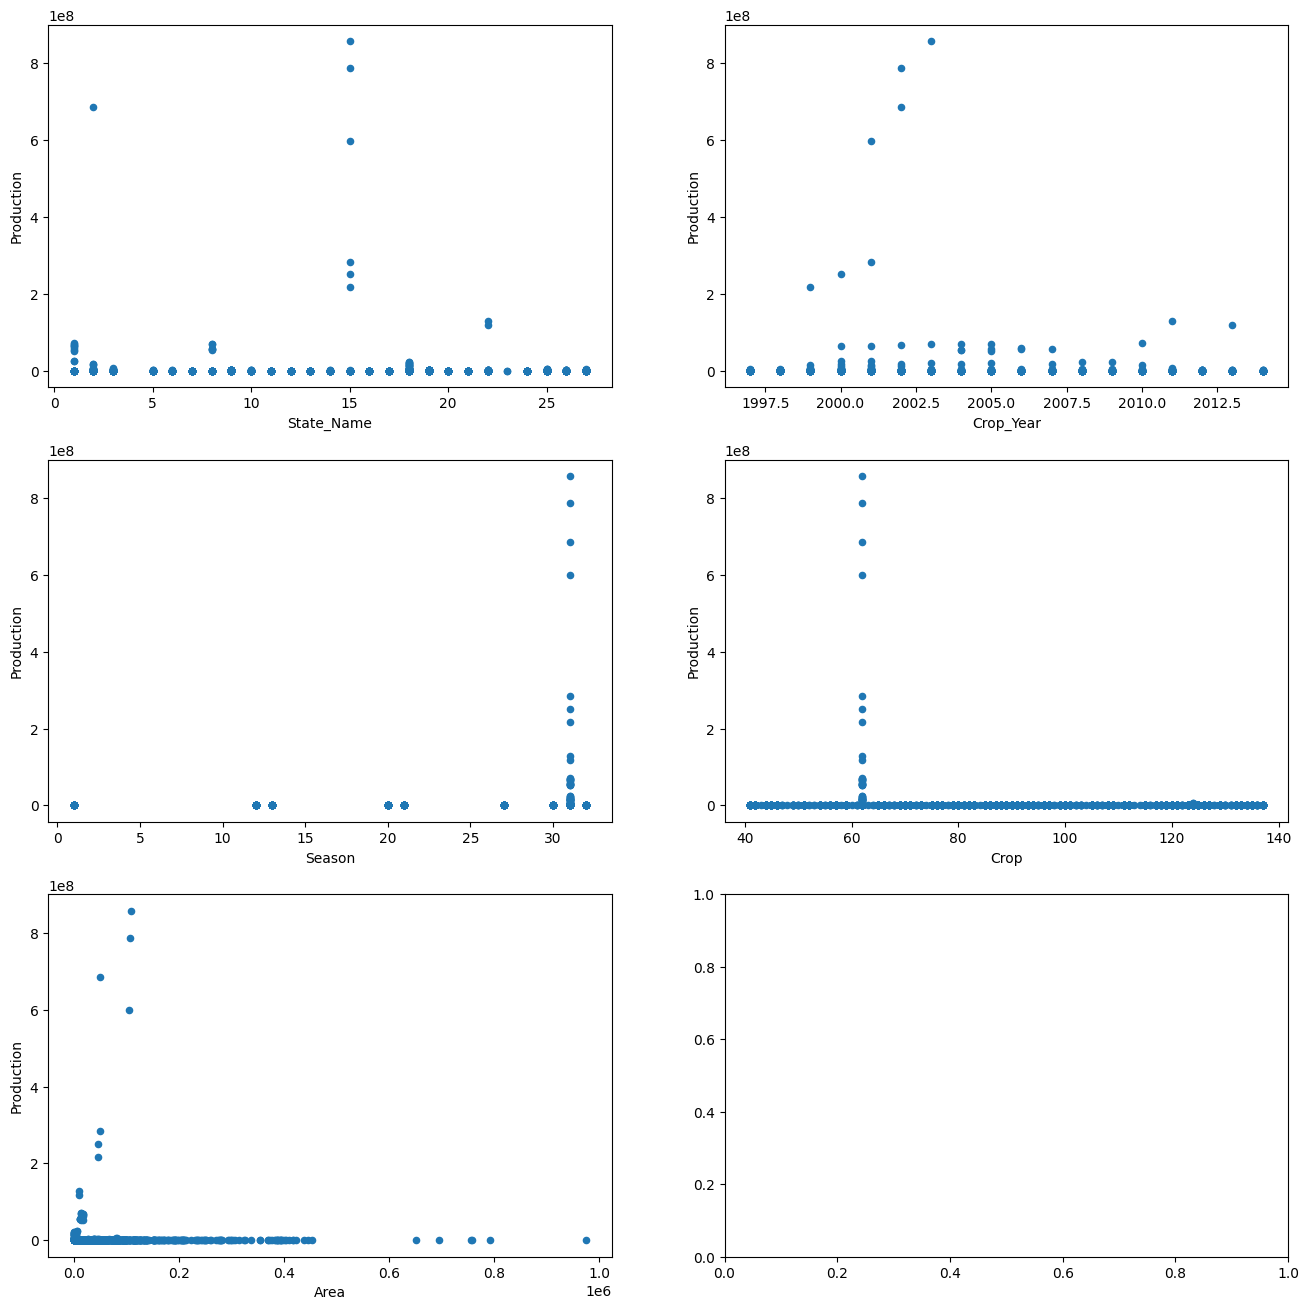

In [ ]:
# Convert 'Crop_Year' column to numeric type
data['Crop_Year'] = pd.to_numeric(data['Crop_Year'], errors='coerce').astype('Int64')
# Convert to numeric, handle errors by converting invalid values to NaN, then convert to integer type

data['State_Name'] = data['State_Name'].astype('category')
data['Season'] = data['Season'].astype('category')
data['Crop'] = data['Crop'].astype('category')

fig,ax=plt.subplots(3,2)
data.plot(kind='scatter',x='State_Name',y='Production',ax=ax[0][0],figsize=(16,16)) #Scatter Plot for features vs labels
data.plot(kind='scatter',x='Crop_Year',y='Production',ax=ax[0][1])
data.plot(kind='scatter',x='Season',y='Production',ax=ax[1][0])
data.plot(kind='scatter',x='Crop',y='Production',ax=ax[1][1])
data.plot(kind='scatter',x='Area',y='Production',ax=ax[2][0])
plt.show()

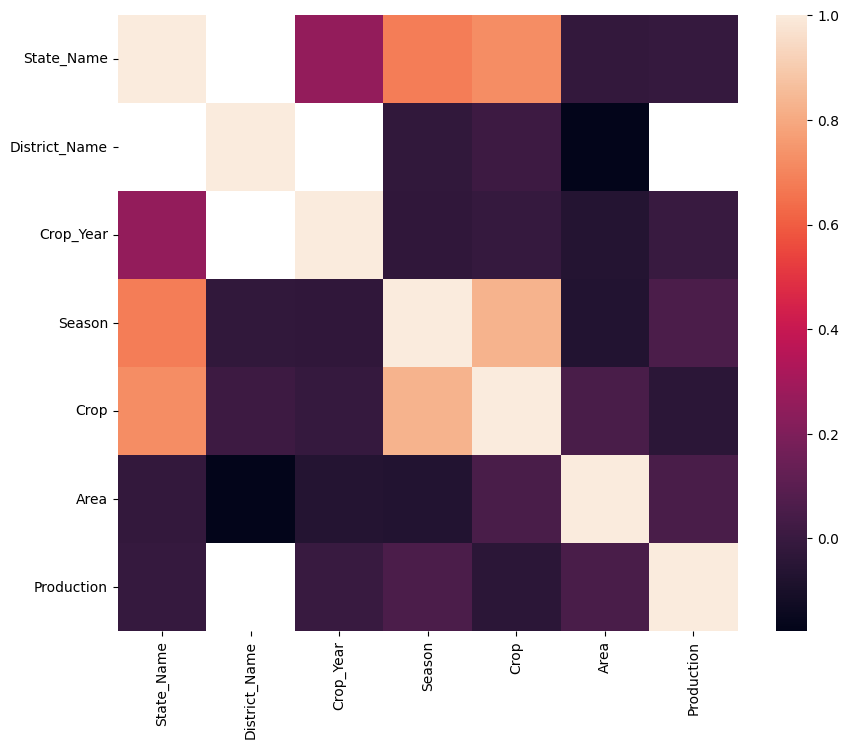

In [ ]:
!pip install seaborn
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt

# Assuming 'data' is your DataFrame

# Convert 'State_Name', 'Season', and 'Crop' columns to categorical type
data['State_Name'] = data['State_Name'].astype('category')
data['Season'] = data['Season'].astype('category')
data['Crop'] = data['Crop'].astype('category')

# Convert 'State_Name', 'Season', and 'Crop' columns to numeric representation
data['State_Name'] = data['State_Name'].cat.codes
data['Season'] = data['Season'].cat.codes
data['Crop'] = data['Crop'].cat.codes

# Convert all columns to numeric type, coercing errors to NaN
numeric_data = data.apply(pd.to_numeric, errors='coerce')

# Drop rows with NaN values
#numeric_data = numeric_data.dropna()

plt.figure(figsize=(10,8))
sns.heatmap(numeric_data.corr()) # Use numeric_data instead of data to ensure only numeric values are used
plt.show()

In [ ]:
x=data.drop(['District_Name'],axis=1)
y=data['Production']
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.3,random_state=10)
x_test


,State_Name,Crop_Year,Season,Crop,Area,Production
4494,-1,<NA>,-1,-1,NaN,NaN
3903,5,2003,31,94,758.0,5549.0
10066,-1,<NA>,-1,-1,NaN,NaN
7782,-1,<NA>,-1,-1,NaN,NaN
10671,18,2007,13,44,64.0,133.0
...,...,...,...,...,...,...
13096,-1,<NA>,-1,-1,NaN,NaN
12099,25,2012,21,112,3014.0,2231.0
7722,-1,<NA>,-1,-1,NaN,NaN
1339,2,1999,13,120,480.0,116.0


In [ ]:
!pip install -q scikit-learn
from sklearn.model_selection import train_test_split # Import the function from the correct module

x=data.drop(['District_Name'],axis=1)
y=data['Production']
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.3,random_state=10)
x_test

,State_Name,Crop_Year,Season,Crop,Area,Production
4494,-1,<NA>,-1,-1,NaN,NaN
3903,5,2003,31,94,758.0,5549.0
10066,-1,<NA>,-1,-1,NaN,NaN
7782,-1,<NA>,-1,-1,NaN,NaN
10671,18,2007,13,44,64.0,133.0
...,...,...,...,...,...,...
13096,-1,<NA>,-1,-1,NaN,NaN
12099,25,2012,21,112,3014.0,2231.0
7722,-1,<NA>,-1,-1,NaN,NaN
1339,2,1999,13,120,480.0,116.0


In [ ]:
x_train = x_train.fillna(x_train.mean())
y_train = y_train.fillna(y_train.mean())
x_test = x_test.fillna(x_test.mean())
y_test = y_test.fillna(y_test.mean())


TypeError: Invalid value '2002.8208375893769' for dtype Int64

In [ ]:
x_train = x_train.fillna(round(x_train.mean())) # Round the mean value to the nearest integer before filling
y_train = y_train.fillna(round(y_train.mean())) # Round the mean value to the nearest integer before filling
x_test = x_test.fillna(round(x_test.mean())) # Round the mean value to the nearest integer before filling
y_test = y_test.fillna(round(y_test.mean())) # Round the mean value to the nearest integer before filling

In [ ]:
regr = RandomForestRegressor(max_depth=200, random_state=0,
                             n_estimators=100)
regr.fit(x_train,y_train)
print(regr.feature_importances_)


[2.31038488e-03 9.05863565e-03 5.71588382e-09 2.17650005e-07
 2.43370105e-02 9.64293746e-01]


In [ ]:
!pip install -q scikit-learn
from sklearn.ensemble import RandomForestRegressor # Import the RandomForestRegressor class

regr = RandomForestRegressor(max_depth=200, random_state=0,
                             n_estimators=100)
regr.fit(x_train,y_train)
print(regr.feature_importances_)

[2.31038488e-03 9.05863565e-03 5.71588382e-09 2.17650005e-07
 2.43370105e-02 9.64293746e-01]


In [ ]:
y_pred=regr.predict(x_test)
y_pred

array([6.1810033e+05, 5.5448500e+03, 6.1810033e+05, ..., 6.1810033e+05,
       1.1588000e+02, 6.1810033e+05])

In [ ]:
regr.score(x_test,y_test)

0.9891993443643414

In [ ]:
regr.score(x_train,y_train)

0.9917455911173362